# 6단계 · 시장 국면 판별 전략

## 개요
**MA 정렬 + ADX 조합** — 기관·퀀트에서 가장 널리 쓰이는 시장 국면 판별 방법입니다.

| 국면 | 판별 조건 | 적용 전략 |
|------|----------|----------|
| **강한 상승 추세장** | MA20 > MA60 > MA120 AND ADX > 25 | 골든크로스 (추세 추종) |
| **강한 하락 추세장** | MA20 < MA60 < MA120 AND ADX > 25 | 공매도 or 현금 보유 |
| **횡보장** | MA 정렬 흐트러짐 AND ADX < 20 | 볼린저 밴드 (평균 회귀) |
| **조정 구간** | 장기 추세 유효 AND 단기 MA 꺾임 | 관망 or 부분 청산 |
| **추세 전환** | MA 데드크로스 AND ADX 상승 | 전략 전환 |

## 학습 목표
1. MA 3중 구조(20/60/120)로 단기·중기·장기 추세 정렬 확인
2. ADX로 추세 강도 수치화
3. 두 조건을 결합해 시장 국면 자동 판별
4. 국면별 최적 전략 자동 전환(스위처) 구현 및 성과 비교

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import vectorbt as vbt
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드 (AAPL 2018~2023)
ticker = 'AAPL'
df = yf.download(ticker, start='2018-01-01', end='2023-12-31',
                 auto_adjust=True, progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

close  = df['Close']
high   = df['High']
low    = df['Low']
volume = df['Volume']

print(f'데이터 기간: {close.index[0].date()} ~ {close.index[-1].date()}')
print(f'총 거래일: {len(close)}일')

데이터 기간: 2018-01-02 ~ 2023-12-29
총 거래일: 1509일


---
## 1단계 · MA 3중 구조 (20 / 60 / 120)

### 정렬 패턴 해석

```
MA20 > MA60 > MA120  → 단기·중기·장기 모두 상승 정렬 = 강한 상승 추세
MA20 < MA60 < MA120  → 단기·중기·장기 모두 하락 정렬 = 강한 하락 추세
MA20 ≈ MA60 교차 반복 → 방향성 없음 = 횡보장
MA20 < MA60 > MA120  → 중기 꺾임, 장기 유효 = 조정 구간
```

### MA 기간이 20/60/120인 이유
| MA | 거래일 기준 | 의미 |
|----|------------|------|
| MA20 | 약 1개월 | 단기 시장 심리 |
| MA60 | 약 3개월(분기) | 중기 추세, 실적 사이클과 정합 |
| MA120 | 약 6개월(반기) | 장기 추세, 섹터 순환과 정합 |

In [2]:
# ─── MA 3중 구조 계산 ──────────────────────────────────────────────
ma20  = close.rolling(20).mean()
ma60  = close.rolling(60).mean()
ma120 = close.rolling(120).mean()

# ─── 정렬 상태 판별 ────────────────────────────────────────────────
bull_align = (ma20 > ma60) & (ma60 > ma120)   # 상승 정렬
bear_align = (ma20 < ma60) & (ma60 < ma120)   # 하락 정렬
mixed      = ~bull_align & ~bear_align         # 혼재 (횡보/조정)

print('=== MA 정렬 상태 분포 ===')
print(f'상승 정렬 (Bull): {bull_align.sum()}일 ({bull_align.mean():.1%})')
print(f'하락 정렬 (Bear): {bear_align.sum()}일 ({bear_align.mean():.1%})')
print(f'혼재 (횡보/조정): {mixed.sum()}일 ({mixed.mean():.1%})')

=== MA 정렬 상태 분포 ===
상승 정렬 (Bull): 728일 (48.2%)
하락 정렬 (Bear): 193일 (12.8%)
혼재 (횡보/조정): 588일 (39.0%)


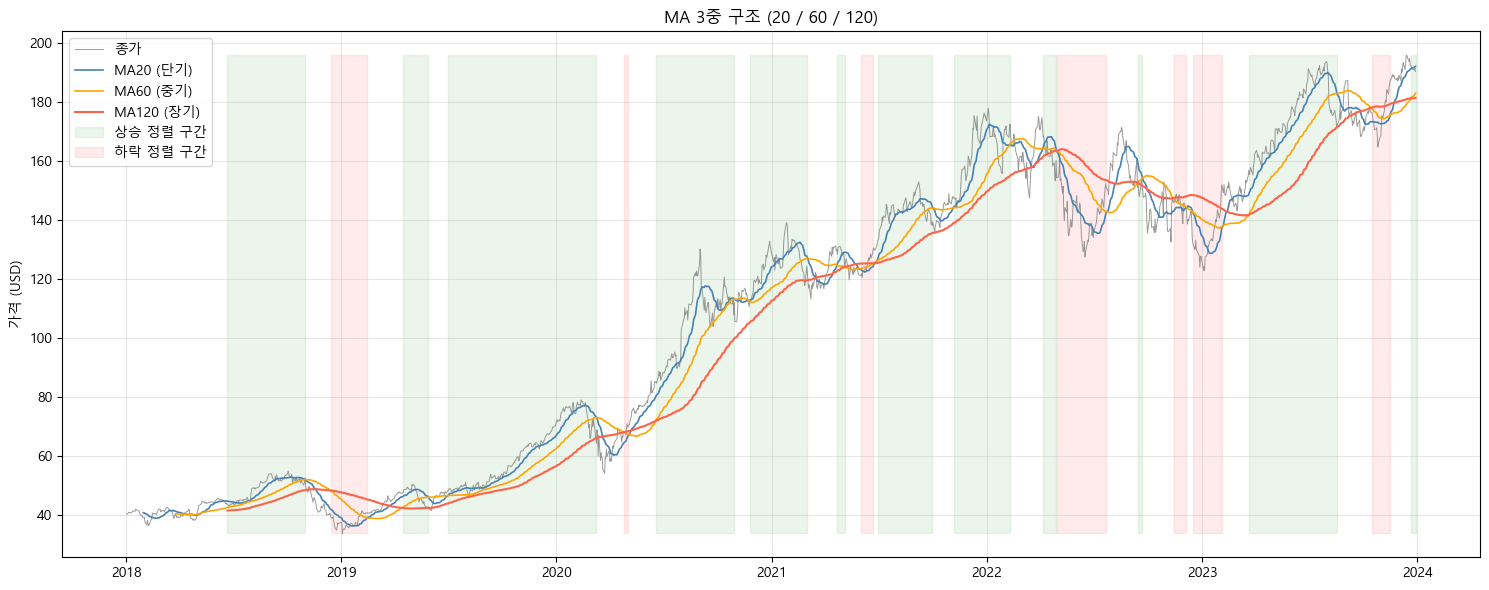

In [3]:
# ─── MA 3중 구조 시각화 ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(close,  color='gray',      linewidth=0.7, alpha=0.8, label='종가')
ax.plot(ma20,   color='steelblue', linewidth=1.2, label='MA20 (단기)')
ax.plot(ma60,   color='orange',    linewidth=1.2, label='MA60 (중기)')
ax.plot(ma120,  color='tomato',    linewidth=1.5, label='MA120 (장기)')

# 상승 정렬 구간 배경 표시
ax.fill_between(close.index, close.min(), close.max(),
                where=bull_align, alpha=0.08, color='green', label='상승 정렬 구간')
ax.fill_between(close.index, close.min(), close.max(),
                where=bear_align, alpha=0.08, color='red', label='하락 정렬 구간')

ax.set_title('MA 3중 구조 (20 / 60 / 120)')
ax.set_ylabel('가격 (USD)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2단계 · ADX 추세 강도 확인

MA 정렬만으로는 추세가 실제로 힘이 있는지 알 수 없습니다.  
ADX를 추가해 **정렬 + 강도** 두 조건을 모두 충족할 때만 추세장으로 확정합니다.

```
ADX < 20   → 추세 약함 (횡보 가능성)
ADX 20~25  → 과도기 (관망)
ADX 25~40  → 중간 추세 (진입 적기)
ADX > 40   → 강한 추세 (추격 매수 주의)
```

In [4]:
# ─── ADX 계산 (vbt_backtest 모듈 활용) ────────────────────────────
from vbt_backtest.strategies.indicators.adx_strategy import calc_adx

adx_df   = calc_adx(high, low, close, window=14)
adx      = adx_df['ADX']
plus_di  = adx_df['plus_di']
minus_di = adx_df['minus_di']

print('=== ADX 통계 ===')
print(f'평균 ADX: {adx.mean():.1f}')
print(f'ADX < 20 (횡보):    {(adx < 20).sum()}일 ({(adx < 20).mean():.1%})')
print(f'ADX 20~25 (과도기): {((adx >= 20) & (adx < 25)).sum()}일')
print(f'ADX > 25 (추세장):  {(adx > 25).sum()}일 ({(adx > 25).mean():.1%})')
print(f'ADX > 40 (강추세):  {(adx > 40).sum()}일 ({(adx > 40).mean():.1%})')

=== ADX 통계 ===
평균 ADX: 27.3
ADX < 20 (횡보):    413일 (27.4%)
ADX 20~25 (과도기): 270일
ADX > 25 (추세장):  813일 (53.9%)
ADX > 40 (강추세):  190일 (12.6%)


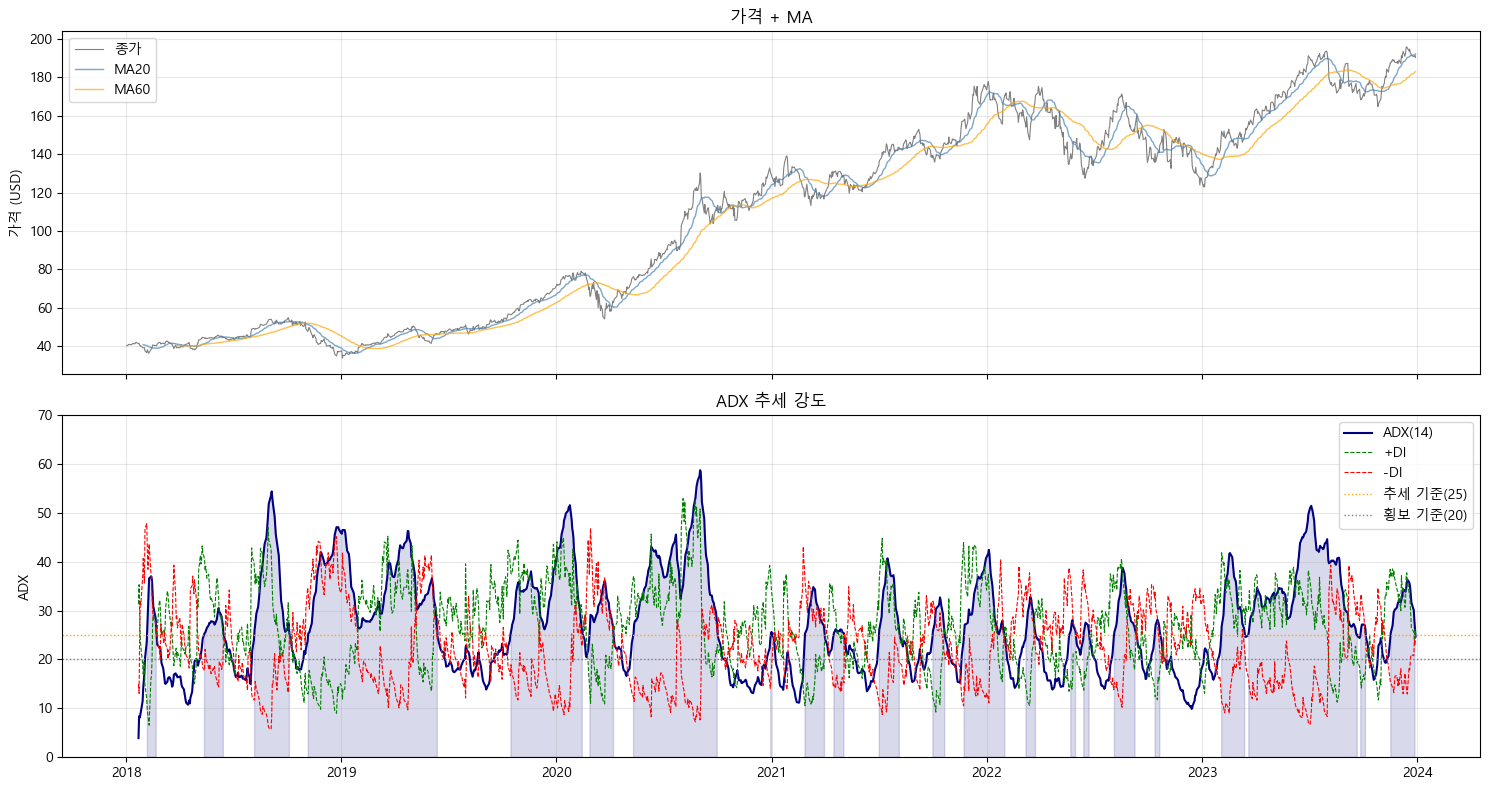

In [5]:
# ─── ADX 시각화 ────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax1.plot(close, color='gray', linewidth=0.8, label='종가')
ax1.plot(ma20,  color='steelblue', linewidth=1.0, alpha=0.7, label='MA20')
ax1.plot(ma60,  color='orange',    linewidth=1.0, alpha=0.7, label='MA60')
ax1.set_title('가격 + MA')
ax1.set_ylabel('가격 (USD)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2.plot(adx,      color='navy',   linewidth=1.5, label='ADX(14)')
ax2.plot(plus_di,  color='green',  linewidth=0.8, linestyle='--', label='+DI')
ax2.plot(minus_di, color='red',    linewidth=0.8, linestyle='--', label='-DI')
ax2.axhline(25, color='orange', linewidth=1.0, linestyle=':', label='추세 기준(25)')
ax2.axhline(20, color='gray',   linewidth=1.0, linestyle=':', label='횡보 기준(20)')
ax2.fill_between(adx.index, 0, adx, where=(adx > 25), alpha=0.15, color='navy')
ax2.set_title('ADX 추세 강도')
ax2.set_ylabel('ADX')
ax2.set_ylim(0, 70)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3단계 · 시장 국면 자동 판별

MA 정렬 + ADX를 결합해 5가지 국면으로 분류합니다.

| 국면 | MA 조건 | ADX 조건 | 색상 |
|------|---------|---------|------|
| 강한 상승 추세 | Bull 정렬 | > 25 | 초록 |
| 약한 상승 추세 | Bull 정렬 | ≤ 25 | 연초록 |
| 강한 하락 추세 | Bear 정렬 | > 25 | 빨강 |
| 약한 하락 추세 | Bear 정렬 | ≤ 25 | 연빨강 |
| 횡보 / 조정 | 혼재 | — | 회색 |

In [6]:
# ─── 시장 국면 분류 ────────────────────────────────────────────────
STRONG_BULL = bull_align & (adx > 25)   # 강한 상승 추세
WEAK_BULL   = bull_align & (adx <= 25)  # 약한 상승 추세
STRONG_BEAR = bear_align & (adx > 25)   # 강한 하락 추세
WEAK_BEAR   = bear_align & (adx <= 25)  # 약한 하락 추세
RANGING     = mixed                      # 횡보 / 조정

# 국면 라벨 Series
regime = pd.Series('횡보/조정', index=close.index)
regime[WEAK_BULL]   = '약한 상승 추세'
regime[STRONG_BULL] = '강한 상승 추세'
regime[WEAK_BEAR]   = '약한 하락 추세'
regime[STRONG_BEAR] = '강한 하락 추세'

print('=== 시장 국면 분포 ===')
counts = regime.value_counts()
for name, cnt in counts.items():
    print(f'  {name:12s}: {cnt}일 ({cnt/len(regime):.1%})')

=== 시장 국면 분포 ===
  횡보/조정       : 588일 (39.0%)
  강한 상승 추세    : 432일 (28.6%)
  약한 상승 추세    : 296일 (19.6%)
  약한 하락 추세    : 137일 (9.1%)
  강한 하락 추세    : 56일 (3.7%)


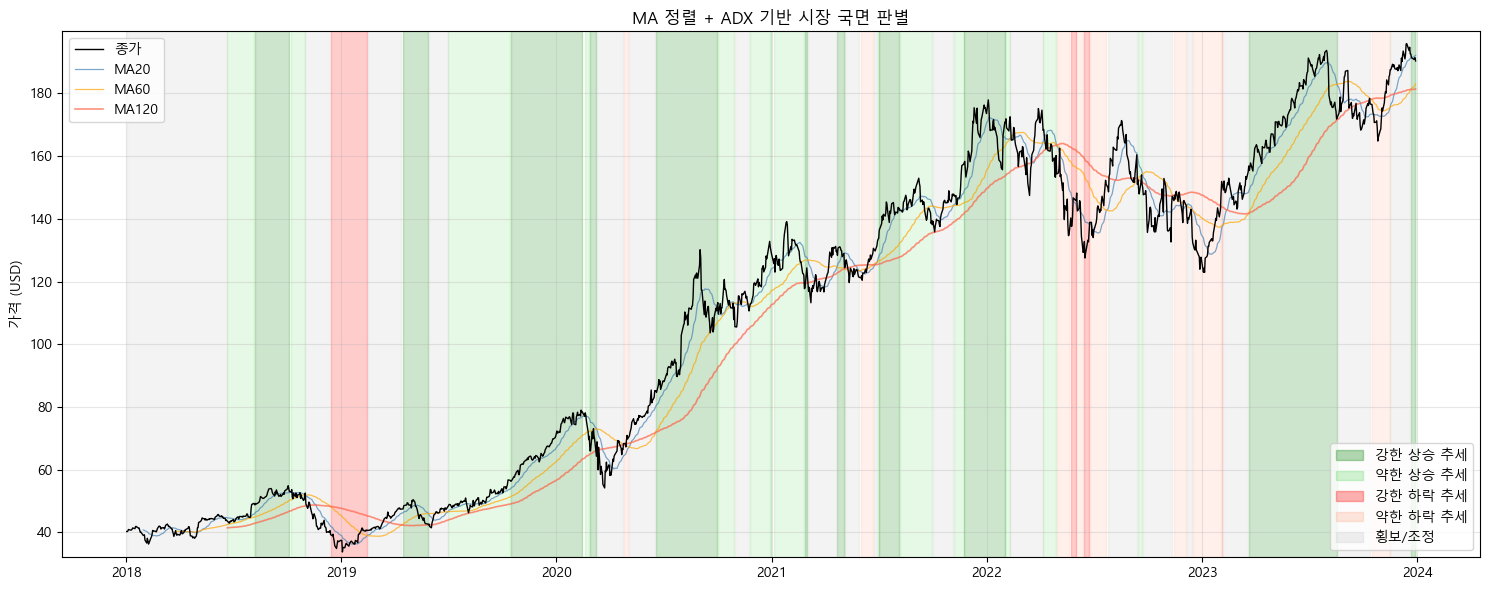

In [7]:
# ─── 국면별 가격 차트 시각화 ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))

regime_styles = {
    'STRONG_BULL': (STRONG_BULL, 'green',      '강한 상승 추세',  0.20),
    'WEAK_BULL':   (WEAK_BULL,   'limegreen',  '약한 상승 추세',  0.12),
    'STRONG_BEAR': (STRONG_BEAR, 'red',         '강한 하락 추세', 0.20),
    'WEAK_BEAR':   (WEAK_BEAR,   'lightsalmon', '약한 하락 추세', 0.15),
    'RANGING':     (RANGING,     'lightgray',   '횡보/조정',      0.25),
}

ymin, ymax = close.min() * 0.95, close.max() * 1.02
patches = []
for key, (mask, color, label, alpha) in regime_styles.items():
    ax.fill_between(close.index, ymin, ymax, where=mask,
                    color=color, alpha=alpha)
    patches.append(mpatches.Patch(color=color, alpha=alpha + 0.1, label=label))

ax.plot(close, color='black', linewidth=1.0, label='종가', zorder=5)
ax.plot(ma20,  color='steelblue', linewidth=0.9, alpha=0.7, label='MA20')
ax.plot(ma60,  color='orange',    linewidth=0.9, alpha=0.7, label='MA60')
ax.plot(ma120, color='tomato',    linewidth=1.2, alpha=0.7, label='MA120')

ax.set_title('MA 정렬 + ADX 기반 시장 국면 판별')
ax.set_ylabel('가격 (USD)')
ax.set_ylim(ymin, ymax)
line_legend = ax.legend(loc='upper left')
ax.add_artist(line_legend)
ax.legend(handles=patches, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4단계 · 국면별 전략 적용 + 포지션 크기 조절

### 3전략 국면 매핑

| 국면 | 적용 전략 | 포지션 크기 | 이유 |
|------|----------|-----------|------|
| 강한 상승 추세 (STRONG_BULL) | 골든크로스 | **100%** | 추세 확인 → 풀 포지션 |
| 약한 상승 추세 (WEAK_BULL) | RSI 역추세 | **50%** | 조정 구간 — 추세 살아있으나 불확실 |
| 횡보 / 조정 (RANGING) | 볼린저 밴드 | **50%** | 박스권 — 방향 불확실 |
| 강한/약한 하락 추세 | 미진입 | **0%** | 하락 추세 진입 금지 |

### 포지션 크기 조절이 중요한 이유
- 모든 신호를 동일 비중으로 진입하면 **불확실한 구간과 확실한 구간의 리스크가 같아짐**
- 강한 추세 확인 시 비중 확대, 불확실 구간 비중 축소로 **기대수익 대비 리스크를 최적화**

In [8]:
# ─── 전략 1: 골든크로스 (강한 상승 추세 전용) ────────────────────
from vbt_backtest.strategies.base.golden_cross import make_signals as gc_signals

gc_entries_raw, gc_exits_raw = gc_signals(close, fast_window=20, slow_window=60)
gc_entries = gc_entries_raw & STRONG_BULL
gc_exits   = gc_exits_raw

# ─── 전략 2: RSI 역추세 (약한 상승 추세 = 조정 구간 전용) ──────────
from vbt_backtest.strategies.base.rsi_strategy import calc_rsi

rsi = calc_rsi(close, window=14)
rsi_entries_raw = (rsi > 30) & (rsi.shift(1) <= 30)   # 과매도 해소
rsi_exits_raw   = (rsi < 70) & (rsi.shift(1) >= 70)   # 과매수 해소

# WEAK_BULL: 장기 추세는 살아있으나 ADX 약함 → 조정 구간
rsi_entries = rsi_entries_raw & WEAK_BULL
rsi_exits   = rsi_exits_raw

# ─── 전략 3: 볼린저 밴드 (횡보/조정 구간 전용) ───────────────────
from vbt_backtest.strategies.base.bollinger_band import make_signals as bb_signals

bb_entries_raw, bb_exits_raw = bb_signals(close, window=20, num_std=2.0)
bb_entries = bb_entries_raw & RANGING
bb_exits   = bb_exits_raw

print('=== 국면 필터 적용 후 신호 수 ===')
print(f'골든크로스 (STRONG_BULL):  {gc_entries_raw.sum():3d}회 → 필터 후 {gc_entries.sum():3d}회')
print(f'RSI 역추세 (WEAK_BULL):    {rsi_entries_raw.sum():3d}회 → 필터 후 {rsi_entries.sum():3d}회')
print(f'볼린저밴드 (RANGING):       {bb_entries_raw.sum():3d}회 → 필터 후 {bb_entries.sum():3d}회')

=== 국면 필터 적용 후 신호 수 ===
골든크로스 (STRONG_BULL):   15회 → 필터 후   1회
RSI 역추세 (WEAK_BULL):     14회 → 필터 후   0회
볼린저밴드 (RANGING):        31회 → 필터 후  14회


In [9]:
# ─── 3전략 신호 병합 (스위처) ─────────────────────────────────────
# 국면이 겹치지 않으므로 OR로 단순 합산 가능
switcher_entries = gc_entries | rsi_entries | bb_entries
switcher_exits   = gc_exits   | rsi_exits   | bb_exits

print(f'스위처 총 매수 신호: {switcher_entries.sum()}회')
print(f'  └ 골든크로스:   {gc_entries.sum()}회')
print(f'  └ RSI 역추세:   {rsi_entries.sum()}회')
print(f'  └ 볼린저밴드:   {bb_entries.sum()}회')

스위처 총 매수 신호: 15회
  └ 골든크로스:   1회
  └ RSI 역추세:   0회
  └ 볼린저밴드:   14회


---
## 5단계 · 포지션 크기 조절 (Position Sizing)

신호 병합만으로는 모든 진입을 동일 비중으로 취급합니다.  
**국면 신뢰도에 따라 투자 비중을 차등 적용**하면 리스크 대비 수익을 높일 수 있습니다.

```
STRONG_BULL → 골든크로스 진입 → 100% (추세 완전 확인)
WEAK_BULL   → RSI 진입        →  50% (조정 구간, 불확실)
RANGING     → 볼린저밴드 진입  →  50% (횡보, 방향 불명)
하락 추세    → 미진입           →   0%
```

vectorbt의 `size` + `size_type='targetpercent'`로 구현합니다.

In [10]:
# ─── 진입 시점별 포지션 크기 매핑 ────────────────────────────────
# NaN: 신호 없음 (기존 포지션 유지)
# 0.0~1.0: 포트폴리오 대비 목표 비중

size_series = pd.Series(np.nan, index=close.index, dtype=float)
size_series[gc_entries]  = 1.0   # 강한 추세 → 100%
size_series[rsi_entries] = 0.5   # 조정 구간 → 50%
size_series[bb_entries]  = 0.5   # 횡보 구간 → 50%

# 청산 시점은 0%로 설정
exits_combined = gc_exits | rsi_exits | bb_exits
size_series[exits_combined] = 0.0

print('=== 포지션 크기 분포 ===')
print(f'100% 진입 (골든크로스): {(size_series == 1.0).sum()}회')
print(f' 50% 진입 (RSI/BB):    {(size_series == 0.5).sum()}회')
print(f'  0% 청산:             {(size_series == 0.0).sum()}회')

# ─── 포지션 크기 조절 포트폴리오 ──────────────────────────────────
pf_sized = vbt.Portfolio.from_orders(
    close,
    size=size_series,
    size_type='targetpercent',
    fees=0.001,
    slippage=0.001,
    freq='D',
)

print('\n=== 포지션 크기 조절 전략 성과 ===')
print(f'총 수익률  : {pf_sized.total_return():.2%}')
print(f'연평균수익률: {pf_sized.annualized_return():.2%}')
print(f'샤프 비율  : {pf_sized.sharpe_ratio():.2f}')
print(f'최대 낙폭  : {pf_sized.max_drawdown():.2%}')

=== 포지션 크기 분포 ===
100% 진입 (골든크로스): 1회
 50% 진입 (RSI/BB):    14회
  0% 청산:             106회

=== 포지션 크기 조절 전략 성과 ===
총 수익률  : 2.42%
연평균수익률: 0.58%
샤프 비율  : 0.11
최대 낙폭  : -19.79%


---
## 6단계 · 전략 종합 백테스트 비교

In [11]:
# ─── 비교 대상 포트폴리오 ─────────────────────────────────────────
def run_pf(entries, exits):
    return vbt.Portfolio.from_signals(
        close, entries, exits,
        fees=0.001, slippage=0.001, freq='D'
    )

# Buy & Hold
bh_e = pd.Series(False, index=close.index); bh_e.iloc[0] = True
bh_x = pd.Series(False, index=close.index); bh_x.iloc[-1] = True
pf_bh = run_pf(bh_e, bh_x)

# 단독 전략 (필터 없음)
pf_gc_only  = run_pf(gc_entries_raw,  gc_exits_raw)
pf_rsi_only = run_pf(rsi_entries_raw, rsi_exits_raw)
pf_bb_only  = run_pf(bb_entries_raw,  bb_exits_raw)

# 국면 필터 적용 (균등 비중)
pf_switcher = run_pf(switcher_entries, switcher_exits)

# 국면 필터 + 포지션 크기 조절 (pf_sized 는 앞 셀에서 생성)

# ─── 성과 비교 테이블 ─────────────────────────────────────────────
strategies = {
    'Buy & Hold':               pf_bh,
    '골든크로스 단독':             pf_gc_only,
    'RSI 단독':                  pf_rsi_only,
    '볼린저밴드 단독':             pf_bb_only,
    '국면 스위처 (균등 비중)':      pf_switcher,
    '국면 스위처 + 포지션 크기':    pf_sized,
}

rows = []
for name, pf in strategies.items():
    rows.append({
        '전략':      name,
        '총 수익률':  f'{pf.total_return():.2%}',
        '연평균':     f'{pf.annualized_return():.2%}',
        '샤프비율':   f'{pf.sharpe_ratio():.2f}',
        '최대낙폭':   f'{pf.max_drawdown():.2%}',
        '거래횟수':   pf.trades.count() if hasattr(pf, 'trades') else '-',
    })

result_df = pd.DataFrame(rows).set_index('전략')
print('=== 전략 성과 비교 ===')
print(result_df.to_string())

=== 전략 성과 비교 ===
                   총 수익률     연평균  샤프비율     최대낙폭  거래횟수
전략                                                   
Buy & Hold       370.89%  45.47%  1.17  -38.52%     1
골든크로스 단독         194.14%  29.82%  1.10  -21.63%    15
RSI 단독           122.68%  21.37%  0.87  -26.94%     7
볼린저밴드 단독          76.46%  14.72%  0.64  -32.94%    16
국면 스위처 (균등 비중)     5.16%   1.22%  0.16  -36.10%     8
국면 스위처 + 포지션 크기    2.42%   0.58%  0.11  -19.79%    10


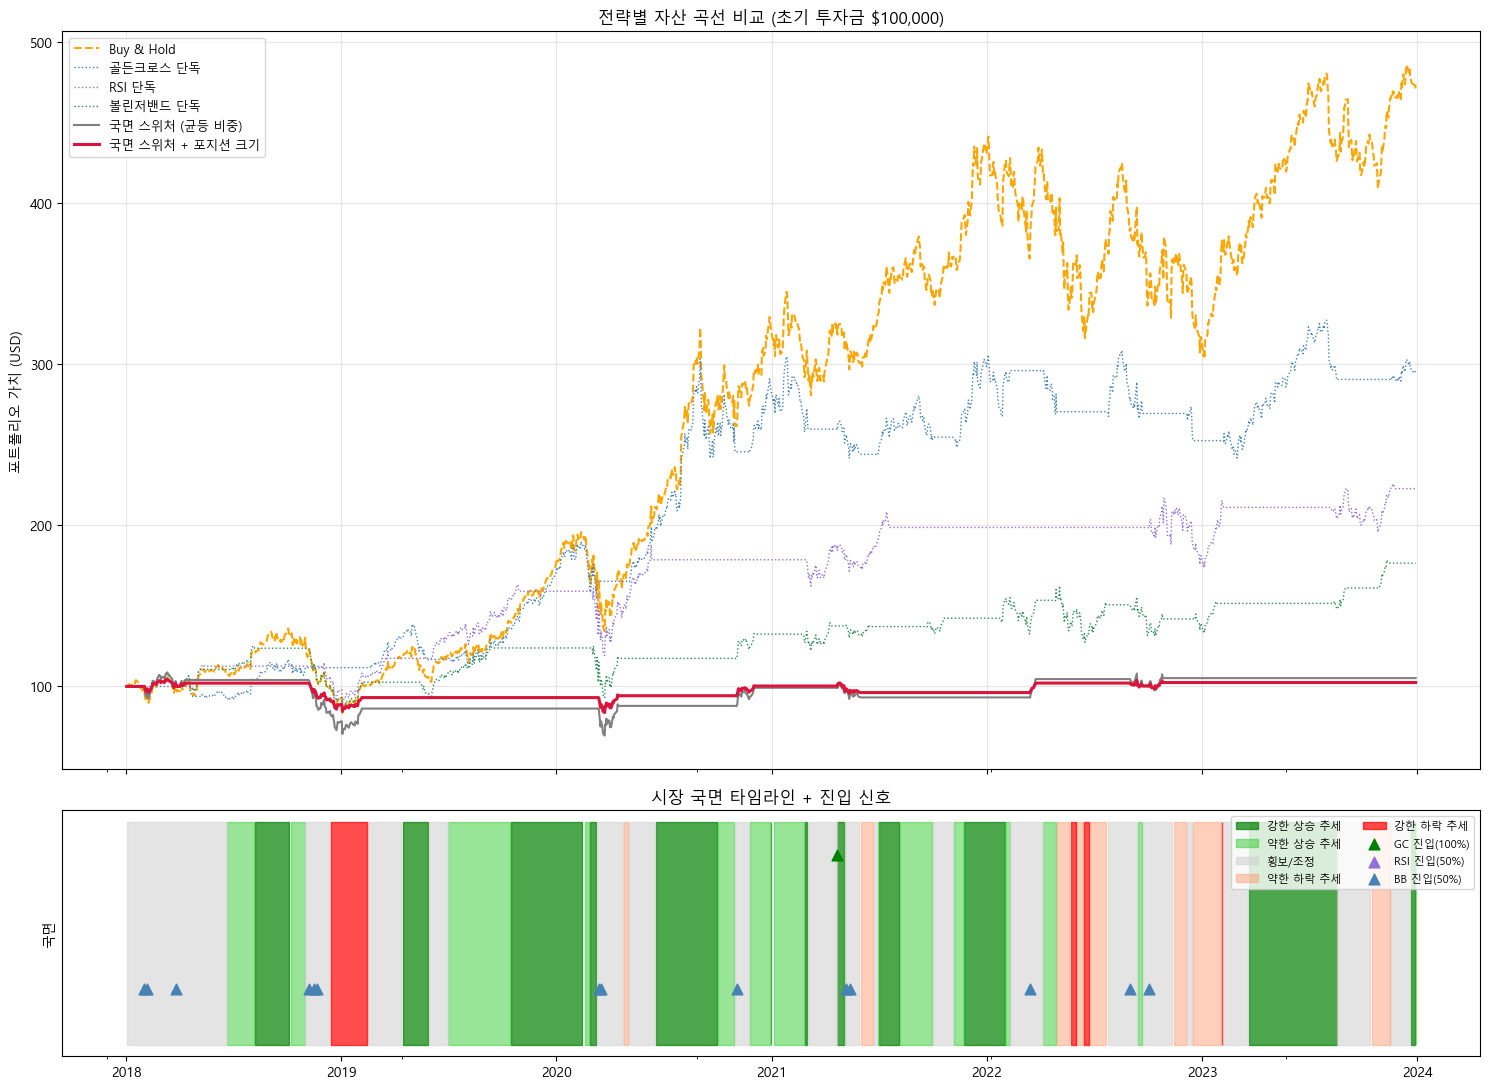

In [12]:
# ─── 자산 곡선 + 국면 타임라인 통합 차트 ─────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 11),
                                sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# 상단: 자산 곡선
style_map = {
    'Buy & Hold':               ('orange',    '--', 1.5),
    '골든크로스 단독':             ('steelblue', ':',  1.0),
    'RSI 단독':                  ('mediumpurple', ':',  1.0),
    '볼린저밴드 단독':             ('seagreen',  ':',  1.0),
    '국면 스위처 (균등 비중)':      ('gray',      '-',  1.5),
    '국면 스위처 + 포지션 크기':    ('crimson',   '-',  2.2),
}

for name, pf in strategies.items():
    color, ls, lw = style_map[name]
    pf.value().plot(ax=ax1, label=name, color=color, linestyle=ls, linewidth=lw)

ax1.set_title('전략별 자산 곡선 비교 (초기 투자금 $100,000)')
ax1.set_ylabel('포트폴리오 가치 (USD)')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# 하단: 국면 타임라인
regime_styles = {
    '강한 상승 추세': ('green',      0.7),
    '약한 상승 추세': ('limegreen',  0.5),
    '횡보/조정':     ('lightgray',  0.6),
    '약한 하락 추세': ('lightsalmon',0.5),
    '강한 하락 추세': ('red',        0.7),
}
for r_name, (r_color, r_alpha) in regime_styles.items():
    ax2.fill_between(close.index, 0, 1,
                     where=(regime == r_name),
                     color=r_color, alpha=r_alpha, label=r_name)

# 진입 신호 마커
ax2.scatter(close.index[gc_entries],  [0.85]*gc_entries.sum(),
            marker='^', color='green',        s=60, zorder=5, label='GC 진입(100%)')
ax2.scatter(close.index[rsi_entries], [0.55]*rsi_entries.sum(),
            marker='^', color='mediumpurple', s=60, zorder=5, label='RSI 진입(50%)')
ax2.scatter(close.index[bb_entries],  [0.25]*bb_entries.sum(),
            marker='^', color='steelblue',   s=60, zorder=5, label='BB 진입(50%)')

ax2.set_title('시장 국면 타임라인 + 진입 신호')
ax2.set_ylabel('국면')
ax2.set_yticks([])
ax2.legend(loc='upper right', fontsize=8, ncol=2)
ax2.grid(False)

plt.tight_layout()
plt.show()

---
## 정리

### 개선 단계별 기대 효과

| 단계 | 내용 | 기대 효과 |
|------|------|----------|
| 단독 전략 | 골든크로스 / RSI / 볼린저밴드 각각 | 기준선 |
| 국면 필터 적용 | 전략마다 맞는 국면에서만 진입 | 거짓 신호 감소, MDD 개선 |
| 3전략 스위처 | 국면별 최적 전략 자동 전환 | 전천후 대응, 공백 구간 축소 |
| **포지션 크기 조절** | 추세 신뢰도에 따라 비중 차등 | **샤프비율 개선, 리스크 최적화** |

### 포지션 크기 조절의 핵심 원리

```
강한 추세 (확신) → 100% 풀 포지션  ← 수익 극대화
조정/횡보 (불확실) →  50% 절반 포지션 ← 손실 제한
하락 추세 (위험) →   0% 미진입      ← 손실 방어
```

불확실한 구간의 손실을 줄이면서 확실한 구간의 수익은 유지 → **샤프비율(수익/리스크 비) 향상**

### 한계 및 주의사항
- **국면 전환 후행성**: MA120 기반이므로 국면 변화 감지에 수주 지연 발생
- **파라미터 의존성**: 20/60/120, ADX 25, 포지션 크기 50% 모두 최적화 대상
- **과최적화 위험**: in-sample에만 맞는 파라미터가 될 수 있으므로 반드시 out-of-sample 검증 필요

### 다음 단계
`04_성과분석_최적화.ipynb` 에서 MA 기간·ADX 임계값·포지션 크기 비율을 그리드 서치로 최적화하고  
in-sample / out-of-sample 분리 검증으로 과최적화 여부를 확인합니다.